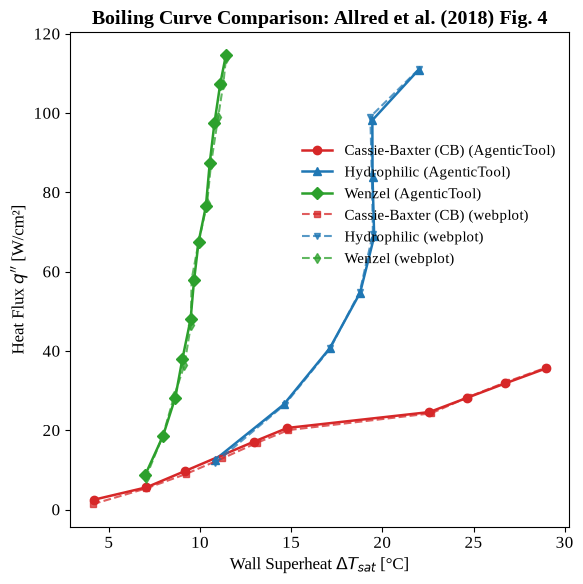

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Font Configuration for Ubuntu / Times New Roman ---
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = [
    "Times New Roman",
    "Liberation Serif",
    "DejaVu Serif",
]
plt.rcParams["font.size"] = 12

# 1. Load CSV Files
df1 = pd.read_csv("../out/boiling_points.csv")
df2 = pd.read_csv("webplot_allred-2018-superhydrophobic-trl.csv")

# 2. Filter for Allred et al. (2018) Fig. 4
df_agentic = df1[df1["paper_id"] == "allred-2018-superhydrophobic-trl"]

# 3. Define Styles and Mapping
styles = {
    "cb": {
        "color": "#d62728",
        "marker_bp": "o",
        "marker_wp": "s",
        "label": "Cassie-Baxter (CB)",
    },
    "hydrophilic": {
        "color": "#1f77b4",
        "marker_bp": "^",
        "marker_wp": "v",
        "label": "Hydrophilic",
    },
    "wenzel": {
        "color": "#2ca02c",
        "marker_bp": "D",
        "marker_wp": "d",
        "label": "Wenzel",
    },
}

wp_mapping = {
    "cb": ("x", "y"),
    "hydrophilic": ("x.1", "y.1"),
    "wenzel": ("x.2", "y.2"),
}

# 4. Plot Figure
fig, ax = plt.subplots(figsize=(6, 6))

# Plot AgenticTool (boiling_points.csv)
for cid, style in styles.items():
  bp_data = df_agentic[df_agentic["curve_id"] == cid]
  ax.plot(
      bp_data["x_value"],
      bp_data["y_value"],
      color=style["color"],
      linestyle="-",
      marker=style["marker_bp"],
      linewidth=1.8,
      markersize=6,
      label=f"{style['label']} (AgenticTool)",
  )

# Plot webplot curves
for cid, (xcol, ycol) in wp_mapping.items():
  style = styles[cid]
  wp_data = df2[[xcol, ycol]].dropna()
  ax.plot(
      wp_data[xcol],
      wp_data[ycol],
      color=style["color"],
      linestyle="--",
      marker=style["marker_wp"],
      linewidth=1.5,
      markersize=5,
      alpha=0.75,
      label=f"{style['label']} (webplot)",
  )

# 5. Formatting & Legend Placement Inside Figure
ax.set_xlabel(r"Wall Superheat $\Delta T_{sat}$ [°C]")
ax.set_ylabel(r"Heat Flux $q''$ [W/cm²]")
ax.set_title(
    "Boiling Curve Comparison: Allred et al. (2018) Fig. 4", fontweight="bold"
)
#ax.grid(True, linestyle="--", alpha=0.5)

# Place legend inside the plot frame without a border
ax.legend(
    loc="center right",
    bbox_to_anchor=(1.0, 0.65),
    frameon=False,
    fontsize=11,
)

plt.tight_layout()
fig.savefig("allred2018_fig4_webplot_comparison.png", dpi=150)
plt.show()

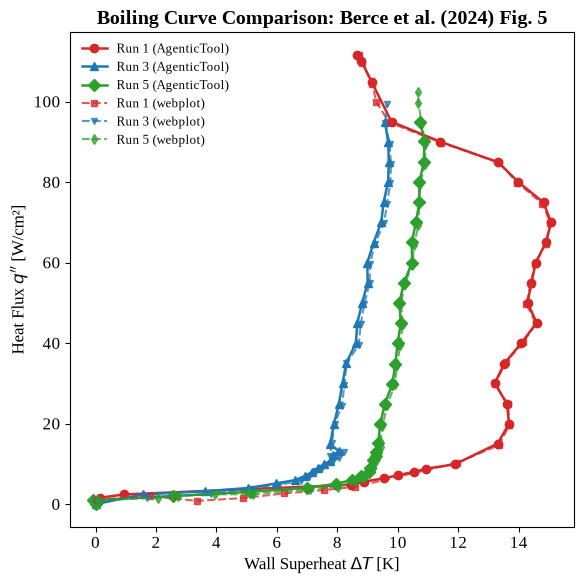

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Font Configuration for Ubuntu / Times New Roman ---
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = [
    "Times New Roman",
    "Liberation Serif",
    "DejaVu Serif",
]
plt.rcParams["font.size"] = 12

df1 = pd.read_csv("../out/boiling_points.csv")
df2 = pd.read_csv("webplot-berce2024.csv")

df1.head()


df_agentic = df1[df1["paper_id"] == "berce-2024-wettability-nanoparticle-deposition"].copy()

# boiling_points.csv reports Berce's heat flux in kW/m^2; the manual (WebPlotDigitizer)
# export is in W/cm^2. Convert AgenticTool's values so both are on the same axis
# (1 W/cm^2 = 10 kW/m^2).
df_agentic["y_value"] = df_agentic["y_value"] / 10.0

df_agentic["curve_id"].value_counts()


styles = {
    "run1": {
        "color": "#d62728",
        "marker_bp": "o",
        "marker_wp": "s",
        "label": "Run 1",
    },
    "run3": {
        "color": "#1f77b4",
        "marker_bp": "^",
        "marker_wp": "v",
        "label": "Run 3",
    },
    "run5": {
        "color": "#2ca02c",
        "marker_bp": "D",
        "marker_wp": "d",
        "label": "Run 5",
    },
}
wp_mapping = {
    "run1": ("x", "y"),
    "run3": ("x.1", "y.1"),
    "run5": ("x.2", "y.2"),
}


fig, ax = plt.subplots(figsize=(6, 6))

# Plot AgenticTool (boiling_points.csv)
for cid, style in styles.items():
    bp_data = df_agentic[df_agentic["curve_id"] == cid]
    ax.plot(
        bp_data["x_value"],
        bp_data["y_value"],
        color=style["color"],
        linestyle="-",
        marker=style["marker_bp"],
        linewidth=1.8,
        markersize=6,
        label=f"{style['label']} (AgenticTool)",
    )

# Plot webplot curves
for cid, (xcol, ycol) in wp_mapping.items():
    style = styles[cid]
    wp_data = df2[[xcol, ycol]].dropna()
    ax.plot(
        wp_data[xcol],
        wp_data[ycol],
        color=style["color"],
        linestyle="--",
        marker=style["marker_wp"],
        linewidth=1.5,
        markersize=5,
        alpha=0.75,
        label=f"{style['label']} (webplot)",
    )

# Formatting & legend
ax.set_xlabel(r"Wall Superheat $\Delta T$ [K]")
ax.set_ylabel(r"Heat Flux $q''$ [W/cm²]")
ax.set_title(
    "Boiling Curve Comparison: Berce et al. (2024) Fig. 5", fontweight="bold"
)
ax.legend(loc="upper left", frameon=False, fontsize=9)

plt.tight_layout()
fig.savefig("berce2024_fig5_webplot_comparison.png", dpi=150)
plt.show()